In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lobster import *

In [82]:
ticker = "INTC"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
table1 = make_descriptive_table(df, K=5)
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df = normalize_by_aes(df, aes=aes, K=5)
df.head()

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,P_-3,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5
0,34200.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1
1,34200.006462,0.000221,L,275500,4,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
2,34200.048864,0.042402,C,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
3,34200.048883,0.000020,C,275100,-1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
4,34200.048989,0.000106,L,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1


In [83]:
ticker_2 = "MSFT"
message_path_2  = f"data/LOBSTER_SampleFile_{ticker_2}_2012-06-21_5/{ticker_2}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path_2 = f"data/LOBSTER_SampleFile_{ticker_2}_2012-06-21_5/{ticker_2}_2012-06-21_34200000_57600000_orderbook_5.csv"


msg_2, ob_2, qr_2, df_2 = load_lobster_data(message_path_2, orderbook_path_2, levels=levels, K=K)
table2 = make_descriptive_table(df_2, K=5)
aes_2 = compute_aes_by_level(df_2, K=5, lvl_col="lvl", size_col="size") 
df_2 = normalize_by_aes(df_2, aes=aes_2, K=5)
df_2.head()

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,P_-3,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5
0,34200.022011,0.022011,L,310200,5,1,309750.0,309800.0,0,309700.0,...,309500.0,1,310100.0,0,309400.0,0,310200.0,1,309300.0,9
1,34200.022344,0.000332,L,310100,4,1,309750.0,309800.0,0,309700.0,...,309500.0,1,310100.0,1,309400.0,0,310200.0,1,309300.0,9
2,34200.022512,0.000168,L,310000,3,1,309750.0,309800.0,0,309700.0,...,309500.0,1,310100.0,1,309400.0,0,310200.0,1,309300.0,9
3,34200.039884,0.017372,M,309600,1,1,309750.0,309800.0,0,309700.0,...,309500.0,1,310100.0,1,309400.0,0,310200.0,1,309300.0,9
4,34200.039884,0.000000,M,309700,1,1,309750.0,309800.0,0,309700.0,...,309500.0,1,310100.0,1,309400.0,0,310200.0,1,309300.0,9


In [103]:
df_sim = pd.read_parquet("mdqr_simulation_full(1).parquet")
df_sim = df_sim.rename(columns={"event_price": "price"})
df_sim["price"] *=50
df_sim["price"] += 275000
df_sim["time"]  += 34199
df_sim

,time,type,lvl,size,Q_1,Q_-1,Q_2,Q_-2,Q_3,Q_-3,Q_4,Q_-4,Q_5,Q_-5,mid_price,price
0,34199.327925,C,-5,5.0,24.0,23.0,31.0,31.0,26.0,28.0,34.0,36.0,33.0,29.0,0.0,274750.0
1,34199.640176,L,4,1.0,24.0,23.0,31.0,31.0,26.0,28.0,35.0,36.0,33.0,29.0,0.0,275200.0
2,34199.670302,C,-4,4.0,24.0,23.0,31.0,31.0,26.0,28.0,35.0,32.0,33.0,29.0,0.0,274800.0
3,34199.871419,L,2,9.0,24.0,23.0,40.0,31.0,26.0,28.0,35.0,32.0,33.0,29.0,0.0,275100.0
4,34200.072491,L,2,1.0,24.0,23.0,41.0,31.0,26.0,28.0,35.0,32.0,33.0,29.0,0.0,275100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347604,57598.711553,L,-3,2.0,0.0,0.0,2.0,1.0,12.0,30.0,11.0,28.0,1.0,32.0,-464.0,251650.0
347605,57598.765647,L,2,1.0,0.0,0.0,3.0,1.0,12.0,30.0,11.0,28.0,1.0,32.0,-464.0,251900.0
347606,57598.896277,M,-2,1.0,0.0,0.0,3.0,0.0,12.0,30.0,11.0,28.0,1.0,32.0,-464.0,251700.0
347607,57598.924464,M,-3,1.0,0.0,0.0,3.0,0.0,12.0,29.0,11.0,28.0,1.0,32.0,-464.0,251650.0


### Prepare DataFrame for correct timings ###

In [104]:
from volatility_functions import extract_price_changes

pc = extract_price_changes(df)
pc_sim = extract_price_changes(df_sim, price_col="price", time_col="time")

In [105]:
display(pc.head())
display(pc_sim.head())

,time,price,dp
0,34200.441108,275100,-100.0
1,34200.649465,275300,200.0
2,34200.783992,275200,-100.0
3,34200.912227,275300,100.0
4,34200.989774,275250,-50.0


,time,price,dp
0,34212.887656,275100.0,50.0
1,34213.493200,275050.0,-50.0
2,34213.499383,275100.0,50.0
3,34213.624233,275050.0,-50.0
4,34219.373589,275100.0,50.0


### Prepare DataFrame for Alternation and Continuation sequences ###

In [106]:
from volatility_functions import compute_alternation_continuation

tick_size = np.min(np.abs(pc["dp"]))
pc = compute_alternation_continuation(pc)

tick_size_sim = np.min(np.abs(pc_sim["dp"]))
pc_sim = compute_alternation_continuation(pc_sim)

### Estimate  $\hat{\eta}_t = \sum_{k=1}^{m} \lambda_{\alpha,t,k} u_{\alpha,t,k}$  ###

with  $ \lambda_{\alpha,t,k} = \frac{N_{\alpha,t,k}^{(a)} + N_{\alpha,t,k}^{(c)}}{\sum_{j=1}^{m} \left[ N_{\alpha,t,j}^{(a)} + N_{\alpha,t,j}^{(c)} \right]} \text{  and  } u_{\alpha,t,k} = \frac{1}{2}\left(k\left(\frac{N_{\alpha,t,k}^{(c)}}{N_{\alpha,t,k}^{(a)}} - 1\right) + 1\right). $

In [107]:
from volatility_functions import estimate_eta_hat

### Efficient Price : $\hat{X}_{\tau_i} = P_{t_i} - \alpha(\frac{1}{2}-\hat\eta)sgn(P_{t_i} - P_{t_{i-1}})$ ##

In [108]:
from volatility_functions import compute_efficient_price

### Realized Volatility : $ \widehat{RV_t} = \sum_{i=1}^{N_{\alpha, t}}(\log(\hat{X}_{\tau_i}) - \log(\hat{X}_{\tau_i-1}))^2$

In [109]:
from volatility_functions import compute_realized_variance

### Rolling Window computing $\hat\eta_t$, $\hat{X}_{\tau_i}$ and $\widehat{RV_t}$ ###

In [ ]:
from volatility_functions import rolling_microstructure_volatility

pc_rolling = rolling_microstructure_volatility(pc, window_seconds=5*60, tick_size=tick_size, min_price_changes=0)

In [ ]:
pc_rolling_sim = rolling_microstructure_volatility(pc_sim, window_seconds=5*60, tick_size=tick_size_sim, min_price_changes=0)

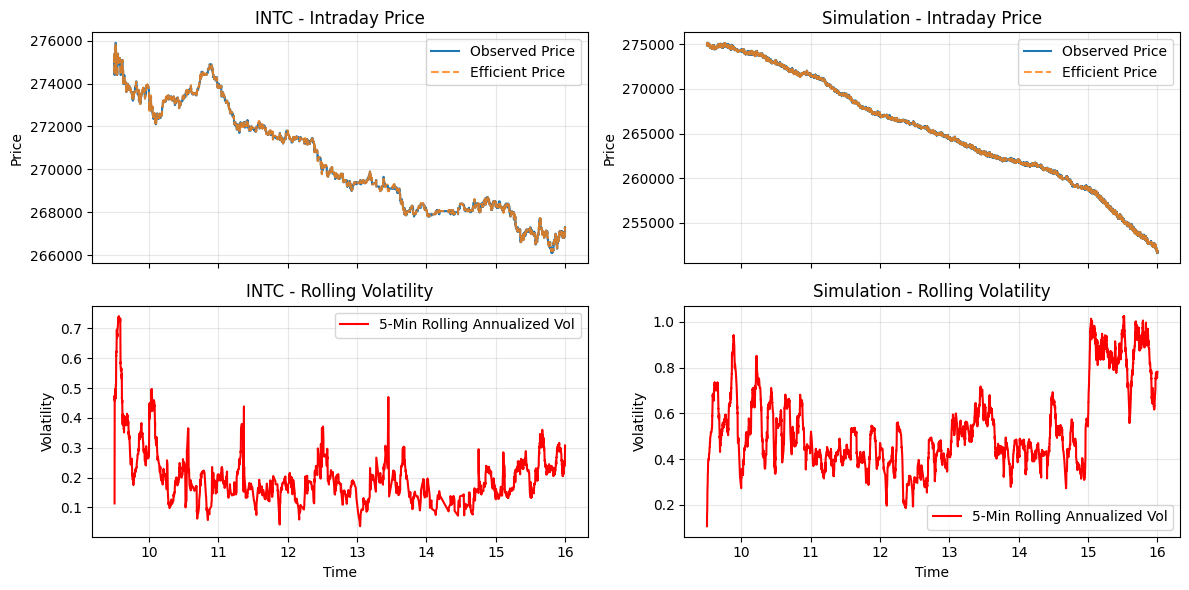

In [111]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex='col')

# =======================
# Colonne gauche : INTC
# =======================

# Haut gauche : prix observé vs prix efficient
axs[0, 0].step(pc_rolling['time'] / 3600, pc_rolling['price'],
               label='Observed Price', alpha=1.0)
axs[0, 0].step(pc_rolling['time'] / 3600, pc_rolling['X_hat_rolling'],
               label='Efficient Price', alpha=0.8, linestyle='--')
axs[0, 0].set_ylabel('Price')
axs[0, 0].set_title(f'INTC - Intraday Price')
axs[0, 0].legend(loc='best')
axs[0, 0].grid(True, alpha=0.3)

# Bas gauche : vol rolling
axs[1, 0].plot(pc_rolling['time'] / 3600, pc_rolling['annualized_vol'],
               label='5-Min Rolling Annualized Vol', color="red")
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Volatility')
axs[1, 0].set_title('INTC - Rolling Volatility')
axs[1, 0].legend(loc='best')
axs[1, 0].grid(True, alpha=0.3)

# =======================
# Colonne droite : simulation
# =======================

# Haut droite : prix observé vs prix efficient
axs[0, 1].step(pc_rolling_sim['time'] / 3600, pc_rolling_sim['price'],
               label='Observed Price', alpha=1.0)
axs[0, 1].step(pc_rolling_sim['time'] / 3600, pc_rolling_sim['X_hat_rolling'],
               label='Efficient Price', alpha=0.8, linestyle='--')
axs[0, 1].set_ylabel('Price')
axs[0, 1].set_title('Simulation - Intraday Price')
axs[0, 1].legend(loc='best')
axs[0, 1].grid(True, alpha=0.3)

# Bas droite : vol rolling
axs[1, 1].plot(pc_rolling_sim['time'] / 3600, pc_rolling_sim['annualized_vol'],
               label='5-Min Rolling Annualized Vol', color="red")
axs[1, 1].set_xlabel('Time')
axs[1, 1].set_ylabel('Volatility')
axs[1, 1].set_title('Simulation - Rolling Volatility')
axs[1, 1].legend(loc='best')
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [127]:
df_vol = pc_rolling[["time", "annualized_vol"]].copy()

def get_period(t):
    total_seconds = t
    
    if total_seconds < 11.0 * 3600:
        return "1-market_opening"
    elif total_seconds < 15.0 * 3600:
        return "2-mid_day"
    else:
        return "3-market_closing"
    
df_vol["period"] = df_vol["time"].map(get_period)
vol_by_period = df_vol.groupby("period")["annualized_vol"].mean()

print(vol_by_period)

period
1-market_opening    0.357238
2-mid_day           0.173779
3-market_closing    0.234398
Name: annualized_vol, dtype: float64


In [113]:
from functions_part2 import plot_scaling_and_xi

qs = np.array([0.5, 1.0, 1.5, 2.0, 3.0])
deltas = np.unique(np.round(np.logspace(0, 1.73, 100)).astype(int))

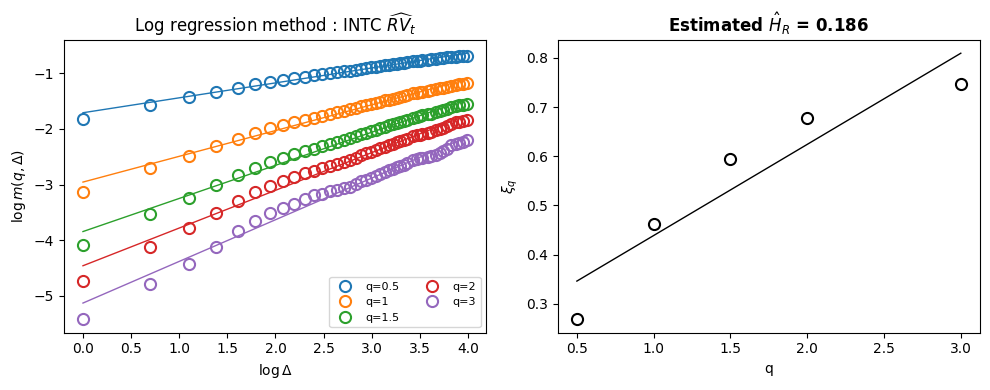

In [114]:
HR_sigma, xi_sigma, m_sigma = plot_scaling_and_xi(
    V=pc_rolling["annualized_vol"].values,
    deltas=deltas,
    qs=qs,
    title_left=r"Log regression method : INTC $\widehat{RV}_t$",
    title_right="Estimated",
    eps=1e-10,               # bump eps slightly, sigma can be tiny
    fit_intercept=True
)

In [115]:
qs = np.array([0.5, 1.0, 1.5, 2.0, 3.0])
deltas = np.unique(np.round(np.logspace(0, 1.73, 100)).astype(int))

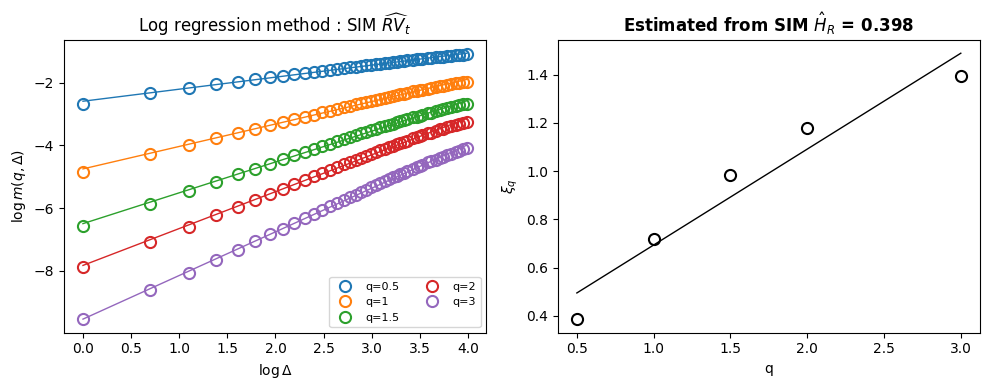

In [116]:
HR_sigma_sim, xi_sigma_sim, m_sigma_sim = plot_scaling_and_xi(
    V=pc_rolling_sim["annualized_vol"].values,
    deltas=deltas,
    qs=qs,
    title_left=r"Log regression method : SIM $\widehat{RV}_t$",
    title_right="Estimated from SIM",
    eps=1e-10,               # bump eps slightly, sigma can be tiny
    fit_intercept=True
)